<a href="https://colab.research.google.com/github/jay-nakrani/image-segmantation/blob/main/IMPROVED_MODEL1_MODEL2_overlay_labels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Segmentation - Model 1 vs Model 2 (Improved for Book/Airplane)

**What changed in this version:**
- Both models now train max 40 epochs (early stopping can stop sooner).
- Model 2 gets stronger oversampling for book and airplane images.
- Model 2 loss gives book and airplane much higher weight so it stops ignoring them.
- Extra augmentation (flip + brightness) added so rare classes are seen more often.
- Comments are written in simple student language to explain each step.

## Step 1: Import Libraries

In [1]:
# To install the packages this notebook needs.
!pip install tensorflow opencv-python matplotlib numpy pillow scikit-learn pycocotools seaborn -q

# To bring in all the tools used later in the notebook.
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pycocotools.coco import COCO
import skimage.io as io
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import jaccard_score, f1_score
import os

%matplotlib inline

# To make results repeat the same way every time we run the notebook.
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print('Libraries imported.')

Libraries imported.


## Step 2: Colors and Class Names

In [2]:
# To give each class the same color in every picture we draw.
class_colors_rgb = {
    0: [0, 0, 0],        # background - BLACK
    1: [255, 0, 0],      # person - RED
    2: [0, 255, 0],      # car - GREEN
    3: [0, 0, 255],      # book - BLUE
    4: [255, 255, 0]     # airplane - YELLOW
}

target_classes = ["person", "car", "book", "airplane"]
class_names = ['background'] + target_classes

# To turn a mask of class numbers into a colored picture we can look at.
def convert_mask_to_colored_image(mask, class_colors_rgb):
    colored = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
    for class_id, rgb_color in class_colors_rgb.items():
        mask_pixels = (mask == class_id)
        colored[mask_pixels] = rgb_color
    return colored

print('Colors set up.')

Colors set up.


## Step 3: Mount Google Drive

In [3]:
# To connect Google Drive so we can reach the dataset folder.
from google.colab import drive
drive.mount("/content/drive")
print('Drive mounted.')

Mounted at /content/drive
Drive mounted.


## Step 4: Data Paths

In [4]:
# To point the notebook to the folder where the images and labels live.
base_path = "/content/drive/MyDrive/RMDS_segmentation_dataset_ADE20K_350"

train_data_path = os.path.join(base_path, "train")
train_annotation_file = os.path.join(base_path, "instances_train.json")

val_data_path = os.path.join(base_path, "val")
val_annotation_file = os.path.join(base_path, "instances_val.json")

test_data_path = os.path.join(base_path, "test")

print('Paths are ready.')

Paths are ready.


## Step 5: Load COCO Annotations

In [5]:
# To load the label files using the COCO tool, so we get boxes and masks easily.
coco_train = COCO(train_annotation_file)
coco_val = COCO(val_annotation_file)

category_IDs = coco_train.getCatIds()
categories = coco_train.loadCats(category_IDs)

print(f'COCO loaded. Total categories: {len(categories)}')

loading annotations into memory...
Done (t=1.09s)
creating index...
index created!
loading annotations into memory...
Done (t=0.48s)
creating index...
index created!
COCO loaded. Total categories: 100


## Step 6: Helper Functions

In [6]:
# To find the class name that matches a class ID number.
def get_category_name(class_ID, categories):
    for cat in categories:
        if cat["id"] == class_ID:
            return cat["name"]
    return "None"

# To build one mask picture where each pixel holds the class number it belongs to.
def create_mask(image_info, annotations_list, coco_api, target_classes):
    height = image_info["height"]
    width = image_info["width"]
    mask = np.zeros((height, width), dtype=np.uint8)

    for annotation in annotations_list:
        class_name = get_category_name(annotation["category_id"], categories)
        if class_name not in target_classes:
            continue
        pixel_value = target_classes.index(class_name) + 1
        ann_mask = coco_api.annToMask(annotation)
        mask = np.maximum(ann_mask * pixel_value, mask)

    return mask

print('Helper functions ready.')

Helper functions ready.


## Step 7: Collect Images That Contain Our Classes

In [7]:
# To gather every training image that has at least one of our 4 target classes in it.
target_classes_IDs = coco_train.getCatIds(catNms=target_classes)

training_images = []
for class_name in target_classes:
    cat_ids = coco_train.getCatIds(catNms=class_name)
    img_ids = coco_train.getImgIds(catIds=cat_ids)
    images = coco_train.loadImgs(img_ids)
    print(f'{class_name}: {len(img_ids)} training images')
    training_images += images

unique_training_images = []
for img in training_images:
    if img not in unique_training_images:
        unique_training_images.append(img)
random.shuffle(unique_training_images)

print(f'Unique training images: {len(unique_training_images)}')

person: 233 training images
car: 148 training images
book: 51 training images
airplane: 5 training images
Unique training images: 350


In [8]:
# To do the same collection step for the validation set.
validation_images = []
for class_name in target_classes:
    cat_ids = coco_val.getCatIds(catNms=class_name)
    img_ids = coco_val.getImgIds(catIds=cat_ids)
    images = coco_val.loadImgs(img_ids)
    print(f'{class_name}: {len(img_ids)} validation images')
    validation_images += images

unique_validation_images = []
for img in validation_images:
    if img not in unique_validation_images:
        unique_validation_images.append(img)
random.shuffle(unique_validation_images)

print(f'Unique validation images: {len(unique_validation_images)}')

person: 239 validation images
car: 136 validation images
book: 46 validation images
airplane: 7 validation images
Unique validation images: 350


## Step 8: Build the Image and Mask Arrays

In [9]:
IMAGE_SIZE = 256

# To resize an image and scale its pixels between 0 and 1.
def load_and_process_image(image_path):
    image = io.imread(image_path)
    if len(image.shape) == 2:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    if image.shape[2] == 4:
        image = image[:, :, :3]
    image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
    image = image / 255.0
    return image

# To resize a mask without mixing up class numbers (nearest neighbor keeps them exact).
def load_and_process_mask(mask):
    mask = cv2.resize(mask, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_NEAREST)
    return mask

# To loop through a list of images and turn them into arrays ready for the model.
def create_dataset(image_list, data_path, coco_api, categories, target_classes):
    images = []
    masks = []

    for idx, img_info in enumerate(image_list):
        img_path = os.path.join(data_path, img_info['file_name'])

        if os.path.exists(img_path):
            try:
                image = load_and_process_image(img_path)
                ann_ids = coco_api.getAnnIds(
                    imgIds=img_info['id'],
                    catIds=coco_api.getCatIds(catNms=target_classes),
                    iscrowd=None
                )
                annotations = coco_api.loadAnns(ann_ids)
                mask = create_mask(img_info, annotations, coco_api, target_classes)
                mask = load_and_process_mask(mask)

                images.append(image)
                masks.append(mask)
            except Exception:
                pass

        if (idx + 1) % 50 == 0:
            print(f'  {idx + 1}/{len(image_list)} processed')

    return np.array(images, dtype=np.float32), np.array(masks, dtype=np.int32)

print('Processing training images...')
X_train, y_train = create_dataset(unique_training_images, train_data_path, coco_train, categories, target_classes)

print('Processing validation images...')
X_val, y_val = create_dataset(unique_validation_images, val_data_path, coco_val, categories, target_classes)

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}, y_val:   {y_val.shape}')

Processing training images...
  50/350 processed
  100/350 processed
  150/350 processed
  200/350 processed
  250/350 processed
  300/350 processed
  350/350 processed
Processing validation images...
  50/350 processed
  100/350 processed
  150/350 processed
  200/350 processed
  250/350 processed
  300/350 processed
  350/350 processed
X_train: (350, 256, 256, 3), y_train: (350, 256, 256)
X_val:   (350, 256, 256, 3), y_val:   (350, 256, 256)


## Step 9: Look at the Class Balance

In [10]:
# To count how many pixels belong to each class, so we know how unbalanced the data is.
print('Class pixel share in training data:')
for class_id, class_name in enumerate(class_names):
    count = (y_train == class_id).sum()
    pct = (count / y_train.size) * 100
    print(f'  {class_name:12s}: {pct:6.2f}%')

# To also list which images actually contain book or airplane, since they are so rare.
book_id = target_classes.index('book') + 1
airplane_id = target_classes.index('airplane') + 1

book_image_idx = [i for i in range(len(y_train)) if (y_train[i] == book_id).any()]
airplane_image_idx = [i for i in range(len(y_train)) if (y_train[i] == airplane_id).any()]

print(f'\nTraining images containing book: {len(book_image_idx)}')
print(f'Training images containing airplane: {len(airplane_image_idx)}')

# To remember the TRUE pixel counts before we repeat any images, so class weights
# stay based on real rarity and are not watered down by oversampling later.
original_class_counts = {c: (y_train == c).sum() for c in range(5)}

Class pixel share in training data:
  background  :  93.29%
  person      :   3.99%
  car         :   2.17%
  book        :   0.46%
  airplane    :   0.09%

Training images containing book: 51
Training images containing airplane: 5


## Step 10: Oversample Rare Classes (Book & Airplane)

This is the main fix for the book/airplane problem. The model almost never
sees these classes, so we repeat those training images several extra times.
This does not touch the validation set, only training.

In [11]:
# To repeat rare-class images so the model sees book and airplane much more often.
BOOK_REPEATS = 6
AIRPLANE_REPEATS = 10

extra_idx = []
extra_idx += book_image_idx * BOOK_REPEATS
extra_idx += airplane_image_idx * AIRPLANE_REPEATS

if len(extra_idx) > 0:
    X_extra = X_train[extra_idx]
    y_extra = y_train[extra_idx]
    X_train = np.concatenate([X_train, X_extra], axis=0)
    y_train = np.concatenate([y_train, y_extra], axis=0)

# To shuffle everything again so repeated images are spread through the dataset.
shuffle_idx = np.arange(len(X_train))
np.random.shuffle(shuffle_idx)
X_train = X_train[shuffle_idx]
y_train = y_train[shuffle_idx]

print(f'Training set size after oversampling: {X_train.shape[0]}')
print('New class pixel share in training data:')
for class_id, class_name in enumerate(class_names):
    count = (y_train == class_id).sum()
    pct = (count / y_train.size) * 100
    print(f'  {class_name:12s}: {pct:6.2f}%')

Training set size after oversampling: 706
New class pixel share in training data:
  background  :  93.42%
  person      :   3.19%
  car         :   1.31%
  book        :   1.61%
  airplane    :   0.47%


## Step 11: Data Augmentation (train only)

In [12]:
# To randomly flip the image and change brightness a bit, so the model does not just memorize.
def augment(image, mask):
    # To flip the image left-right half of the time (mask flips the same way).
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask[..., tf.newaxis])[..., 0]

    # To change the brightness a little so the model is not fooled by lighting.
    image = tf.image.random_brightness(image, max_delta=0.15)
    image = tf.clip_by_value(image, 0.0, 1.0)

    return image, mask

# To wrap the arrays into a tf.data pipeline that shuffles, augments and batches.
def make_train_dataset(X, y, batch_size=8):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    ds = ds.map(lambda img, msk: augment(img, msk), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.shuffle(200).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

BATCH_SIZE = 8
train_ds = make_train_dataset(X_train, y_train, batch_size=BATCH_SIZE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print('Datasets ready for training.')

Datasets ready for training.


## Step 12: Class Weights & Loss Function

In [13]:
# To calculate a weight per class, so the model is punished more for missing rare classes.
# IMPORTANT: this uses original_class_counts (before oversampling), not the current
# y_train. If we used the oversampled y_train here, book/airplane would look less
# rare than they really are, and their weight would shrink -- undoing the whole
# point of oversampling them in Step 10.
class_counts = original_class_counts
total_pixels = sum(class_counts.values())
raw_weights = {c: total_pixels / (5 * max(count, 1)) for c, count in class_counts.items()}

# To give book and airplane an extra boost, since even oversampling is not always enough.
manual_boost = {0: 1.0, 1: 1.3, 2: 1.3, 3: 2.2, 4: 2.5}
class_weights_array = np.array([
    min(raw_weights[c] * manual_boost[c], 12.0) for c in range(5)
], dtype=np.float32)

print('Final class weights used in the loss (based on TRUE rarity, not oversampled counts):')
for c, name in enumerate(class_names):
    print(f'  {name:12s}: {class_weights_array[c]:.3f}')

class_weights_tf = tf.constant(class_weights_array)

# To combine weighted cross-entropy with a weighted dice score, which helps small objects a lot.
def weighted_ce_dice_loss(y_true, y_pred, num_classes=5, class_weights=class_weights_tf):
    y_true_int = tf.cast(y_true, tf.int32)
    y_true_onehot = tf.one_hot(y_true_int, num_classes)

    # To compute weighted cross-entropy, so rare classes count more.
    ce = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    pixel_weights = tf.gather(class_weights, y_true_int)
    weighted_ce = tf.reduce_mean(ce * pixel_weights)

    # To compute a weighted dice loss, which looks at overlap area instead of per pixel error.
    y_pred_clipped = tf.clip_by_value(y_pred, 1e-7, 1.0)
    intersection = tf.reduce_sum(y_true_onehot * y_pred_clipped, axis=[1, 2])
    union = tf.reduce_sum(y_true_onehot, axis=[1, 2]) + tf.reduce_sum(y_pred_clipped, axis=[1, 2])
    dice_per_class = (2.0 * intersection + 1e-6) / (union + 1e-6)
    weighted_dice = tf.reduce_sum((1.0 - dice_per_class) * class_weights, axis=-1)
    weighted_dice = tf.reduce_mean(weighted_dice) / tf.reduce_sum(class_weights)

    return weighted_ce + weighted_dice

print('Loss function ready.')

Final class weights used in the loss (based on TRUE rarity, not oversampled counts):
  background  : 0.214
  person      : 6.516
  car         : 11.990
  book        : 12.000
  airplane    : 12.000
Loss function ready.


In [14]:
# To measure mean IoU across all 5 classes during training, which is more honest than accuracy.
class MeanIoUMetric(tf.keras.metrics.Metric):
    def __init__(self, num_classes=5, name='mean_iou', **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.total_iou = self.add_weight(name='total_iou', initializer='zeros')
        self.count = self.add_weight(name='count', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_labels = tf.argmax(y_pred, axis=-1, output_type=tf.int32)
        y_true = tf.cast(y_true, tf.int32)
        ious = []
        for c in range(self.num_classes):
            true_c = tf.equal(y_true, c)
            pred_c = tf.equal(y_pred_labels, c)
            intersection = tf.reduce_sum(tf.cast(true_c & pred_c, tf.float32))
            union = tf.reduce_sum(tf.cast(true_c | pred_c, tf.float32))
            iou = tf.where(union > 0, intersection / union, 0.0)
            ious.append(iou)
        self.total_iou.assign_add(tf.reduce_mean(ious))
        self.count.assign_add(1.0)

    def result(self):
        return self.total_iou / self.count

    def reset_state(self):
        self.total_iou.assign(0.0)
        self.count.assign(0.0)

print('Mean IoU metric ready.')

Mean IoU metric ready.


## Step 13: Model 1 - Custom U-Net

In [15]:
# To build a small U-Net from scratch, with batch norm and L2 to fight overfitting.
def build_unet_custom(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), num_classes=5):
    inputs = keras.Input(shape=input_shape)
    reg = regularizers.l2(1e-4)

    def conv_block(x, filters):
        x = layers.Conv2D(filters, 3, activation='relu', padding='same', kernel_regularizer=reg)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(filters, 3, activation='relu', padding='same', kernel_regularizer=reg)(x)
        x = layers.BatchNormalization()(x)
        return x

    # To shrink the image step by step and pull out features (the encoder).
    c1 = conv_block(inputs, 32); p1 = layers.MaxPooling2D()(c1)
    c2 = conv_block(p1, 64);     p2 = layers.MaxPooling2D()(c2)
    c3 = conv_block(p2, 128);    p3 = layers.MaxPooling2D()(c3)
    c4 = conv_block(p3, 256)

    # To grow the image back up and reuse encoder details (the decoder).
    u5 = layers.UpSampling2D()(c4); u5 = layers.concatenate([u5, c3]); c5 = conv_block(u5, 128)
    u6 = layers.UpSampling2D()(c5); u6 = layers.concatenate([u6, c2]); c6 = conv_block(u6, 64)
    u7 = layers.UpSampling2D()(c6); u7 = layers.concatenate([u7, c1]); c7 = conv_block(u7, 32)

    outputs = layers.Conv2D(num_classes, 1, activation='softmax')(c7)
    return keras.Model(inputs=inputs, outputs=outputs)

model1 = build_unet_custom()
print('Model 1 built.')
model1.summary()

Model 1 built.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_2[

 Total params: 1,952,645 (7.45 MB)

 Trainable params: 1,949,829 (7.44 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [16]:
# To set up training rules: how fast to learn, when to stop, when to slow down.
model1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss=weighted_ce_dice_loss,
    metrics=['accuracy', MeanIoUMetric()]
)

# To watch val_mean_iou instead of val_loss. Loss is mostly driven by the huge
# background class and jumps around a lot, so it can stop training too early even
# while book/airplane are still slowly improving. Mean IoU across all 5 classes is
# a more honest signal of real progress, so we stop on that instead (mode='max').
early_stop_1 = EarlyStopping(monitor='val_mean_iou', mode='max', patience=10, restore_best_weights=True, verbose=1)
reduce_lr_1 = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=3, verbose=1)

print('Training Model 1 (max 40 epochs, will stop early if needed)...')
history1 = model1.fit(
    train_ds,
    epochs=80,
    validation_data=val_ds,
    callbacks=[early_stop_1, reduce_lr_1],
    verbose=1
)

model1.save('model1_custom_unet.h5')
print('Model 1 saved.')

Training Model 1 (max 40 epochs, will stop early if needed)...
Epoch 1/80
89/89 ━━━━━━━━━━━━━━━━━━━━ 89s 563ms/step - accuracy: 0.2751 - loss: 2.2933 - mean_iou: 0.0770 - val_accuracy: 0.9298 - val_loss: 3.6786 - val_mean_iou: 0.1860 - learning_rate: 5.0000e-04
Epoch 2/80
89/89 ━━━━━━━━━━━━━━━━━━━━ 15s 163ms/step - accuracy: 0.3075 - loss: 2.1996 - mean_iou: 0.0865 - val_accuracy: 0.8723 - val_loss: 4.3051 - val_mean_iou: 0.1754 - learning_rate: 5.0000e-04
Epoch 3/80
89/89 ━━━━━━━━━━━━━━━━━━━━ 20s 163ms/step - accuracy: 0.3541 - loss: 2.0920 - mean_iou: 0.1009 - val_accuracy: 0.9036 - val_loss: 3.6622 - val_mean_iou: 0.1935 - learning_rate: 5.0000e-04
Epoch 4/80
89/89 ━━━━━━━━━━━━━━━━━━━━ 15s 165ms/step - accuracy: 0.4042 - loss: 2.0180 - mean_iou: 0.1195 - val_accuracy: 0.7229 - val_loss: 2.7997 - val_mean_iou: 0.1624 - learning_rate: 5.0000e-04
Epoch 5/80
89/89 ━━━━━━━━━━━━━━━━━━━━ 15s 167ms/step - accuracy: 0.4213 - loss: 1.9552 - mean_iou: 0.1272 - val_accuracy: 0.7169 - val_loss: 

Model 1 saved.


## Step 14: Model 2 - Pretrained Encoder U-Net (MobileNetV2)

In [17]:
# To build a U-Net that reuses a pretrained MobileNetV2 as the encoder, which already knows shapes and edges.
def build_unet_pretrained(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), num_classes=5):
    base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')

    # To grab feature maps at different sizes from inside MobileNetV2 for the skip connections.
    skip_names = [
        'block_1_expand_relu',   # 128x128
        'block_3_expand_relu',   # 64x64
        'block_6_expand_relu',   # 32x32
        'block_13_expand_relu',  # 16x16
    ]
    skip_outputs = [base_model.get_layer(name).output for name in skip_names]
    bottleneck = base_model.get_layer('block_16_project').output

    encoder = keras.Model(inputs=base_model.input, outputs=skip_outputs + [bottleneck])
    # To freeze the backbone at first, so we only train the new decoder layers.
    encoder.trainable = False

    inputs = keras.Input(shape=input_shape)
    s1, s2, s3, s4, bottleneck_out = encoder(inputs)

    def decoder_block(x, skip, filters):
        x = layers.UpSampling2D()(x)
        x = layers.concatenate([x, skip])
        x = layers.Conv2D(filters, 3, activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(filters, 3, activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        return x

    # To rebuild the image size step by step, mixing in the matching encoder skip layer each time.
    d1 = decoder_block(bottleneck_out, s4, 256)
    d2 = decoder_block(d1, s3, 128)
    d3 = decoder_block(d2, s2, 64)
    d4 = decoder_block(d3, s1, 32)

    # To bring the output back to the full 256x256 input size.
    d5 = layers.UpSampling2D()(d4)
    d5 = layers.Conv2D(16, 3, activation='relu', padding='same')(d5)

    outputs = layers.Conv2D(num_classes, 1, activation='softmax')(d5)

    model = keras.Model(inputs=inputs, outputs=outputs)
    return model, encoder

model2, encoder2 = build_unet_pretrained()
print('Model 2 built with a pretrained encoder.')
print(f'Total params: {model2.count_params():,}')

/tmp/ipykernel_1619/2137860254.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model 2 built with a pretrained encoder.
Total params: 5,418,085


In [18]:
# To train only the new decoder first, while the pretrained backbone stays frozen.
model2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=weighted_ce_dice_loss,
    metrics=['accuracy', MeanIoUMetric()]
)

# To stop on val_mean_iou (not val_loss) for the same reason as Model 1 -- loss
# is noisy here because of the huge background class, mean IoU is more honest.
early_stop_2a = EarlyStopping(monitor='val_mean_iou', mode='max', patience=10, restore_best_weights=True, verbose=1)
reduce_lr_2a = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=3, verbose=1)

print('=== Phase 1: training decoder, backbone frozen (max 25 epochs) ===')
history2a = model2.fit(
    train_ds,
    epochs=25,
    validation_data=val_ds,
    callbacks=[early_stop_2a, reduce_lr_2a],
    verbose=1
)

=== Phase 1: training decoder, backbone frozen (max 25 epochs) ===
Epoch 1/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 105s 703ms/step - accuracy: 0.4541 - loss: 1.5451 - mean_iou: 0.1596 - val_accuracy: 0.4185 - val_loss: 1.8684 - val_mean_iou: 0.1352 - learning_rate: 0.0010
Epoch 2/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.6546 - loss: 1.2780 - mean_iou: 0.2513 - val_accuracy: 0.6111 - val_loss: 1.5328 - val_mean_iou: 0.1956 - learning_rate: 0.0010
Epoch 3/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - accuracy: 0.7091 - loss: 1.2402 - mean_iou: 0.2782 - val_accuracy: 0.7815 - val_loss: 1.4287 - val_mean_iou: 0.2587 - learning_rate: 0.0010
Epoch 4/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.7885 - loss: 1.1622 - mean_iou: 0.3226 - val_accuracy: 0.5692 - val_loss: 1.7971 - val_mean_iou: 0.2116 - learning_rate: 0.0010
Epoch 5/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.8031 - loss: 1.1275 - mean_iou: 0.3283 - val_accuracy: 0.7795 - val_loss: 1.2812 - val_mean_i

In [19]:
# To unfreeze the last part of the backbone, so it can adjust slightly to our exact classes.
encoder2.trainable = True
for layer in encoder2.layers[:-30]:
    layer.trainable = False

trainable_count = sum(np.prod(v.shape) for v in model2.trainable_weights)
print(f'Trainable params after unfreezing last backbone layers: {trainable_count:,}')

# To use a much smaller learning rate now, so we do not wreck the pretrained weights.
model2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=weighted_ce_dice_loss,
    metrics=['accuracy', MeanIoUMetric()]
)

# To stay consistent with Phase 1, stop on val_mean_iou here too.
early_stop_2b = EarlyStopping(monitor='val_mean_iou', mode='max', patience=8, restore_best_weights=True, verbose=1)
reduce_lr_2b = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=3, verbose=1)

# To keep total epochs for Model 2 at 40 or less, so Phase 1 + Phase 2 together stay within budget.
remaining_epochs = max(40 - len(history2a.history['loss']), 5)

print(f'=== Phase 2: fine-tuning backbone at low learning rate (max {remaining_epochs} epochs) ===')
history2b = model2.fit(
    train_ds,
    epochs=remaining_epochs,
    validation_data=val_ds,
    callbacks=[early_stop_2b, reduce_lr_2b],
    verbose=1
)

model2.save('model2_pretrained_unet.h5')
print('Model 2 saved.')

Trainable params after unfreezing last backbone layers: 4,786,277
=== Phase 2: fine-tuning backbone at low learning rate (max 15 epochs) ===
Epoch 1/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 72s 435ms/step - accuracy: 0.9182 - loss: 1.0518 - mean_iou: 0.4346 - val_accuracy: 0.9059 - val_loss: 1.3900 - val_mean_iou: 0.3460 - learning_rate: 1.0000e-05
Epoch 2/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 33s 88ms/step - accuracy: 0.9159 - loss: 0.9646 - mean_iou: 0.4303 - val_accuracy: 0.9032 - val_loss: 1.3827 - val_mean_iou: 0.3401 - learning_rate: 1.0000e-05
Epoch 3/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - accuracy: 0.9146 - loss: 0.9857 - mean_iou: 0.4269 - val_accuracy: 0.9022 - val_loss: 1.3891 - val_mean_iou: 0.3382 - learning_rate: 1.0000e-05
Epoch 4/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - accuracy: 0.9128 - loss: 0.9887 - mean_iou: 0.4281 - val_accuracy: 0.9029 - val_loss: 1.3948 - val_mean_iou: 0.3399 - learning_rate: 1.0000e-05
Epoch 5/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - accuracy: 0.912

Model 2 saved.


## Step 15: Training Curves

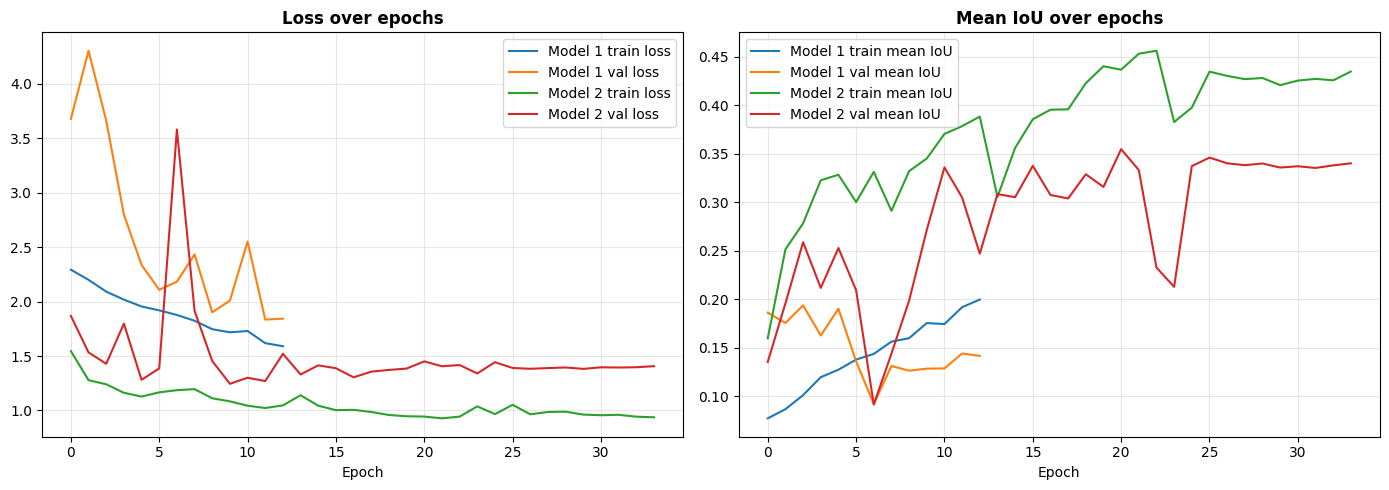

In [20]:
# To combine phase 1 and phase 2 history into one line for Model 2, so we can plot it as one run.
def merge_history(h1, h2):
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history[key]
    return merged

history2_full = merge_history(history2a, history2b)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history1.history['loss'], label='Model 1 train loss')
axes[0].plot(history1.history['val_loss'], label='Model 1 val loss')
axes[0].plot(history2_full['loss'], label='Model 2 train loss')
axes[0].plot(history2_full['val_loss'], label='Model 2 val loss')
axes[0].set_title('Loss over epochs', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history1.history['mean_iou'], label='Model 1 train mean IoU')
axes[1].plot(history1.history['val_mean_iou'], label='Model 1 val mean IoU')
axes[1].plot(history2_full['mean_iou'], label='Model 2 train mean IoU')
axes[1].plot(history2_full['val_mean_iou'], label='Model 2 val mean IoU')
axes[1].set_title('Mean IoU over epochs', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 16: Per-Class Metrics for Both Models

In [21]:
# To turn model output probabilities into a class label per pixel.
def get_predictions(model, X):
    preds = model.predict(X, verbose=0)
    return np.argmax(preds, axis=-1)

# To calculate IoU and F1 for every class on the validation set.
def per_class_metrics(y_true, y_pred_classes):
    results = {}
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred_classes.flatten()
    for class_id, class_name in enumerate(class_names):
        mask_class = (y_true_flat == class_id)
        pred_class = (y_pred_flat == class_id)
        if mask_class.sum() > 0:
            iou = jaccard_score(mask_class, pred_class, zero_division=0)
            f1 = f1_score(mask_class, pred_class, zero_division=0)
        else:
            iou, f1 = 0.0, 0.0
        results[class_name] = (iou, f1)
    return results

y_pred1 = get_predictions(model1, X_val)
y_pred2 = get_predictions(model2, X_val)

metrics1 = per_class_metrics(y_val, y_pred1)
metrics2 = per_class_metrics(y_val, y_pred2)

print('PER-CLASS IoU / F1 -- Model 1 vs Model 2:')
print('=' * 70)
print(f'{"class":12s} | {"M1 IoU":>7s} | {"M2 IoU":>7s} | {"M1 F1":>7s} | {"M2 F1":>7s}')
for class_name in class_names:
    iou1, f1_1 = metrics1[class_name]
    iou2, f1_2 = metrics2[class_name]
    print(f'{class_name:12s} | {iou1:7.4f} | {iou2:7.4f} | {f1_1:7.4f} | {f1_2:7.4f}')
print('=' * 70)

PER-CLASS IoU / F1 -- Model 1 vs Model 2:
class        |  M1 IoU |  M2 IoU |   M1 F1 |   M2 F1
background   |  0.9037 |  0.9013 |  0.9494 |  0.9481
person       |  0.0814 |  0.4030 |  0.1505 |  0.5745
car          |  0.0000 |  0.4445 |  0.0000 |  0.6154
book         |  0.0000 |  0.1355 |  0.0000 |  0.2387
airplane     |  0.0000 |  0.0539 |  0.0000 |  0.1023


## Step 17: Visual Test on 3 Images

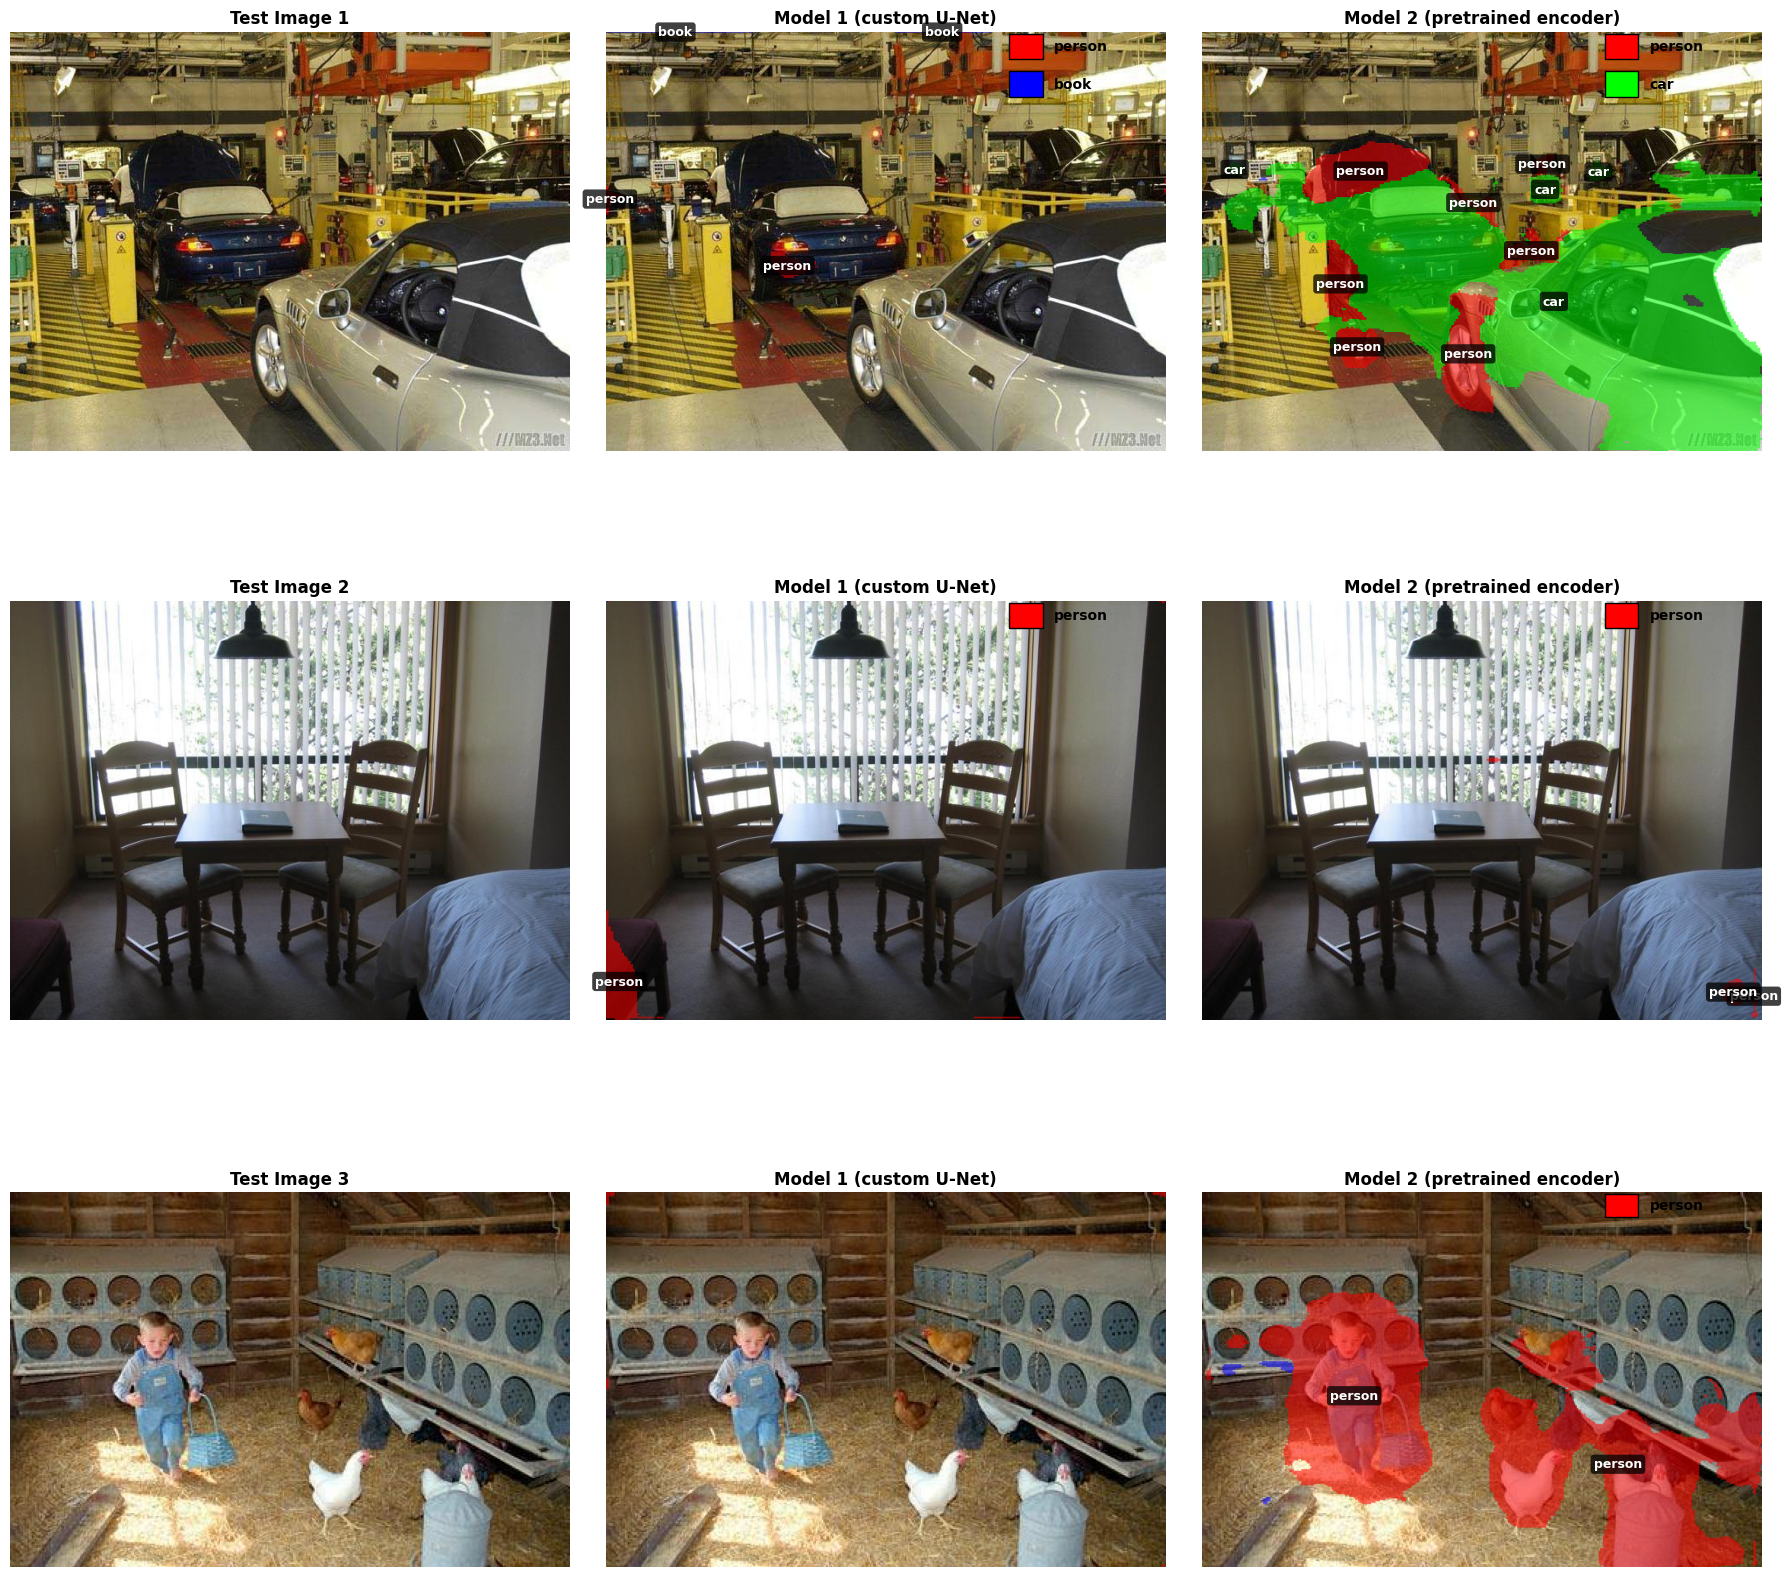

Test evaluation complete.


In [22]:
# To draw a colored, see-through overlay on top of the real photo (like a proper
# segmentation demo), instead of showing the raw mask on its own.
from scipy import ndimage

def overlay_prediction_with_labels(image_path, model, image_size=IMAGE_SIZE, alpha=0.55, min_area=120):
    # To load the original photo at full size, so labels and overlay line up with it.
    original_img = io.imread(image_path)
    if len(original_img.shape) == 2:
        original_img = cv2.cvtColor(original_img, cv2.COLOR_GRAY2RGB)
    if original_img.shape[2] == 4:
        original_img = original_img[:, :, :3]
    orig_h, orig_w = original_img.shape[:2]

    # To run the model at its normal input size, then stretch the prediction back
    # up to the original photo's size using nearest-neighbor (so class IDs stay exact).
    image_resized = cv2.resize(original_img, (image_size, image_size))
    image_norm = image_resized / 255.0
    prediction = model.predict(np.expand_dims(image_norm, axis=0), verbose=0)
    predicted_mask_small = np.argmax(prediction[0], axis=-1).astype(np.uint8)
    predicted_mask = cv2.resize(predicted_mask_small, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)

    # To blend the class color into the photo only where a class was predicted,
    # so the person/book/car/airplane regions glow with color but stay recognizable.
    colored_mask = convert_mask_to_colored_image(predicted_mask, class_colors_rgb).astype(np.float32)
    overlay = original_img.astype(np.float32).copy()
    foreground = predicted_mask != 0
    overlay[foreground] = (1 - alpha) * overlay[foreground] + alpha * colored_mask[foreground]
    overlay = overlay.astype(np.uint8)

    # To find each separate blob per class and label its center, skipping tiny
    # specks under min_area so the image doesn't get cluttered with noise labels.
    label_positions = []
    for class_id, class_name in enumerate(class_names):
        if class_id == 0:
            continue
        class_mask = (predicted_mask == class_id).astype(np.uint8)
        labeled_blobs, n_blobs = ndimage.label(class_mask)
        for blob_id in range(1, n_blobs + 1):
            blob_pixels = (labeled_blobs == blob_id)
            area = int(blob_pixels.sum())
            if area < min_area:
                continue
            ys, xs = np.where(blob_pixels)
            cy, cx = int(ys.mean()), int(xs.mean())
            label_positions.append((class_name, cx, cy))

    return original_img, overlay, predicted_mask, label_positions


def draw_labels_on_axis(ax, overlay_img, label_positions):
    # To show the blended image, then stamp a small black-boxed text label at
    # the center of every detected blob (person, book, car, airplane).
    ax.imshow(overlay_img)
    for class_name, cx, cy in label_positions:
        ax.text(
            cx, cy, class_name,
            color='white', fontsize=9, fontweight='bold',
            ha='center', va='center',
            bbox=dict(facecolor='black', alpha=0.75, boxstyle='round,pad=0.25', edgecolor='none')
        )
    ax.axis('off')


def draw_legend_box(ax, classes_present):
    # To draw a small legend box in the top-right corner showing only the
    # classes that actually appear in this image (not all 5 every time).
    if not classes_present:
        return
    for i, class_name in enumerate(classes_present):
        class_id = class_names.index(class_name)
        color_rgb = tuple(np.array(class_colors_rgb[class_id]) / 255.0)
        y_frac = 0.97 - i * 0.09
        ax.add_patch(mpatches.Rectangle(
            (0.72, y_frac - 0.035), 0.06, 0.06,
            transform=ax.transAxes, facecolor=color_rgb, edgecolor='black', clip_on=False
        ))
        ax.text(0.80, y_frac - 0.005, class_name, transform=ax.transAxes,
                fontsize=10, fontweight='bold', va='center')


# To run both models on the first 3 unlabelled test images and show a clean,
# report-ready side-by-side comparison with overlays, labels and a legend.
test_images = sorted([f for f in os.listdir(test_data_path) if f.endswith('.jpg')])[:3]

fig, axes = plt.subplots(len(test_images), 3, figsize=(18, 6 * len(test_images)))
if len(test_images) == 1:
    axes = axes.reshape(1, 3)

for idx, img_name in enumerate(test_images):
    img_path = os.path.join(test_data_path, img_name)

    original, overlay1, mask1, labels1 = overlay_prediction_with_labels(img_path, model1)
    _, overlay2, mask2, labels2 = overlay_prediction_with_labels(img_path, model2)

    axes[idx, 0].imshow(original)
    axes[idx, 0].set_title(f'Test Image {idx+1}', fontweight='bold')
    axes[idx, 0].axis('off')

    draw_labels_on_axis(axes[idx, 1], overlay1, labels1)
    axes[idx, 1].set_title('Model 1 (custom U-Net)', fontweight='bold')
    classes_present_1 = sorted(set(l[0] for l in labels1), key=target_classes.index)
    draw_legend_box(axes[idx, 1], classes_present_1)

    draw_labels_on_axis(axes[idx, 2], overlay2, labels2)
    axes[idx, 2].set_title('Model 2 (pretrained encoder)', fontweight='bold')
    classes_present_2 = sorted(set(l[0] for l in labels2), key=target_classes.index)
    draw_legend_box(axes[idx, 2], classes_present_2)

plt.tight_layout()
plt.show()

print('Test evaluation complete.')


## Step 18: Overall Metrics Summary

In [23]:
# To print one simple overall score line for each model, easy to paste into the report.
def overall_metrics(y_true, y_pred_classes):
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred_classes.flatten()
    accuracy = (y_true_flat == y_pred_flat).mean()
    iou = jaccard_score(y_true_flat, y_pred_flat, average='weighted', zero_division=0)
    f1 = f1_score(y_true_flat, y_pred_flat, average='weighted', zero_division=0)
    return accuracy, iou, f1

acc1, iou1, f1_1 = overall_metrics(y_val, y_pred1)
acc2, iou2, f1_2 = overall_metrics(y_val, y_pred2)

print('OVERALL METRICS SUMMARY')
print('=' * 60)
print(f'{"metric":15s} | {"Model 1":>10s} | {"Model 2":>10s}')
print(f'{"Accuracy":15s} | {acc1:10.4f} | {acc2:10.4f}')
print(f'{"Weighted IoU":15s} | {iou1:10.4f} | {iou2:10.4f}')
print(f'{"Weighted F1":15s} | {f1_1:10.4f} | {f1_2:10.4f}')
print('=' * 60)
print('\nModel 2 (pretrained encoder) should now show clearly better')
print('book and airplane scores thanks to oversampling and the boosted')
print('class weights in the loss function.')

OVERALL METRICS SUMMARY
metric          |    Model 1 |    Model 2
Accuracy        |     0.9036 |     0.9059
Weighted IoU    |     0.8453 |     0.8663
Weighted F1     |     0.8911 |     0.9213

Model 2 (pretrained encoder) should now show clearly better
book and airplane scores thanks to oversampling and the boosted
class weights in the loss function.
